In [1]:
%pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 4.2 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 88.4 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 97.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 82.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.8/32.8 MB 64.9 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 75.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 87.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 835.9/835.9 kB 98.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 39.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import  LatentDirichletAllocation, NMF
import spacy
import pyLDAvis
import pyLDAvis.lda_model
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import textwrap
import numpy as np
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel
from langdetect import detect, DetectorFactory

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-06 21:28:03.630636: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-06 21:28:03.714056: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-06 21:28:09.889494: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different 

In [3]:
df = pd.read_csv("archelect_search.csv",sep=",")
df = df[df["contexte-election"]=="législatives"]
print(df.shape)

/tmp/ipykernel_1826/913678588.py:1: DtypeWarning: Columns (0: departement-nom, 1: departement-insee, 2: identifiant de circonscription, 3: pdf, 4: suppleant-nom, 5: suppleant-prenom, 6: suppleant-sexe, 7: suppleant-age, 8: suppleant-age-calcule, 9: suppleant-age-tranche, 10: suppleant-profession, 11: suppleant-mandat-en-cours, 12: suppleant-mandat-passe, 13: suppleant-associations, 14: suppleant-autres-statuts, 15: suppleant-soutien, 16: suppleant-liste, 17: suppleant-decorations) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("archelect_search.csv",sep=",")


(32625, 42)


In [4]:
ref = pd.read_csv("archelect_search.csv")

/tmp/ipykernel_1826/572316049.py:1: DtypeWarning: Columns (0: departement-nom, 1: departement-insee, 2: identifiant de circonscription, 3: pdf, 4: suppleant-nom, 5: suppleant-prenom, 6: suppleant-sexe, 7: suppleant-age, 8: suppleant-age-calcule, 9: suppleant-age-tranche, 10: suppleant-profession, 11: suppleant-mandat-en-cours, 12: suppleant-mandat-passe, 13: suppleant-associations, 14: suppleant-autres-statuts, 15: suppleant-soutien, 16: suppleant-liste, 17: suppleant-decorations) have mixed types. Specify dtype option on import or set low_memory=False.
  ref = pd.read_csv("archelect_search.csv")


In [5]:
ref2 = ref[["id","departement","titulaire-profession","titulaire-soutien"]]

In [6]:
import os
import pandas as pd

TEXT_DIR = "1981/legislatives"

def load_texts_from_dir(text_dir):
    texts = []
    meta = []

    for filename in os.listdir(text_dir):
        if not filename.endswith(".txt"):
            continue
        
        path = os.path.join(text_dir, filename)
        doc_id = filename.replace(".txt", "")
        
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read().strip()  # enlever les espaces en début/fin
            if len(text) == 0:
                continue  # ignorer les fichiers vides
        
        texts.append(text)
        meta.append({
            "id": doc_id,
            "text": text
        })

    df = pd.DataFrame(meta)
    print(f"Nombre de documents chargés : {len(df)}")
    return df

# Charger tous les textes
df = load_texts_from_dir(TEXT_DIR)

# Afficher les premières lignes pour vérification
df.head()

Nombre de documents chargés : 3182


,id,text
0,EL135_L_1981_06_059_17_1_PF_02,17e CIRCONSCRIPTION DU NORD\nELECTIONS LEGISLA...
1,EL137_L_1981_06_093_01_2_PF_02,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...
2,EL136_L_1981_06_075_14_1_PF_07,Sciences Po / fonds CEVIPOF\nElections législa...
3,EL137_L_1981_06_077_01_2_PF_01,1re Circonscription\nREPUBLIQUE FRANÇAISE\nDép...
4,EL134_L_1981_06_02A_01_1_PF_03,ELECTIONS LEGISLATIVES DES 14 ET 21 JUIN 1981\...


In [7]:
df2 = df.merge(ref2, how = "left", on="id")

In [8]:
DetectorFactory.seed = 0

def detect_lang(text):
    try:
        return detect(text)
    except:
        return "unknown"

df2["lang"] = df2["text"].apply(detect_lang)

df2 = df2[df2["lang"] == "fr"]

In [9]:
df2.shape

(3157, 6)

In [10]:
STOPWORDS = [x.strip() for x in open('data/stop_word_fr.txt').readlines()]
nlp = spacy.load("fr_core_news_sm", disable=["parser"])
df['lemmatized_text'] = [" ".join([token.lemma_ for token in doc]) for doc in nlp.pipe(df['text'])]

In [11]:
df.to_csv("df.txt",sep=";")

In [12]:
df = pd.read_csv("df.txt",sep=";")

In [13]:
df_vectorizer = CountVectorizer(
    stop_words = STOPWORDS,
    min_df=0.005,
    max_df=0.7,
    ngram_range=(1, 2)
)

X = df_vectorizer.fit_transform(df["lemmatized_text"])

In [57]:
perplexities = []
for k in range(8, 20, 1):
    lda_test = LatentDirichletAllocation(n_components=k, random_state=42, learning_method='batch')
    lda_test.fit(X)
    perplexities.append(lda_test.perplexity(X))
    print(f'Nombre de topics testés: {k} / Perplexité: {lda_test.perplexity(X):.2f}')

Nombre de topics testés: 8 / Perplexité: 2013.02
Nombre de topics testés: 9 / Perplexité: 1984.14
Nombre de topics testés: 10 / Perplexité: 2029.46
Nombre de topics testés: 11 / Perplexité: 2000.55
Nombre de topics testés: 12 / Perplexité: 1944.75
Nombre de topics testés: 13 / Perplexité: 1898.48
Nombre de topics testés: 14 / Perplexité: 1848.23
Nombre de topics testés: 15 / Perplexité: 1861.92
Nombre de topics testés: 16 / Perplexité: 1849.04
Nombre de topics testés: 17 / Perplexité: 1846.48
Nombre de topics testés: 18 / Perplexité: 1823.37
Nombre de topics testés: 19 / Perplexité: 1811.67


In [68]:
perplexities = perplexities[:12]  

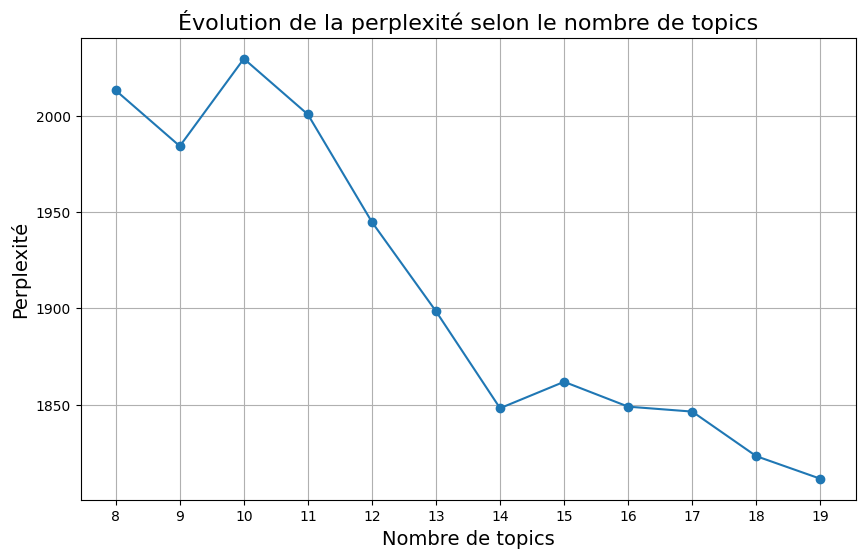

In [69]:
topic_range = list(range(8, 20))

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(topic_range, perplexities, marker='o', linestyle='-')
ax.set_xticks(topic_range)
ax.set_xlabel("Nombre de topics", fontsize=14)
ax.set_ylabel("Perplexité", fontsize=14)
ax.set_title("Évolution de la perplexité selon le nombre de topics", fontsize=16)
ax.grid(True)

plt.show()

In [14]:
lda = LatentDirichletAllocation(
    n_components=14,
    random_state=42,
    learning_method='batch' 
)

lda.fit(X)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",14
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [17]:
def plot_top_words(model, vectorizer, n_top_words, title):
    feature_names = vectorizer.get_feature_names_out()
    n_topics = len(model.components_)

    n_cols = 5
    n_lines = int(np.ceil(n_topics / n_cols))
    fig, axes = plt.subplots(n_lines, n_cols, figsize=(30, 30), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[-n_top_words:]
        top_features = feature_names[top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx + 1}", fontdict={"fontsize": 30})
        ax.tick_params(axis="both", which="major", labelsize=20)
        for i in "top right left".split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=40)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()


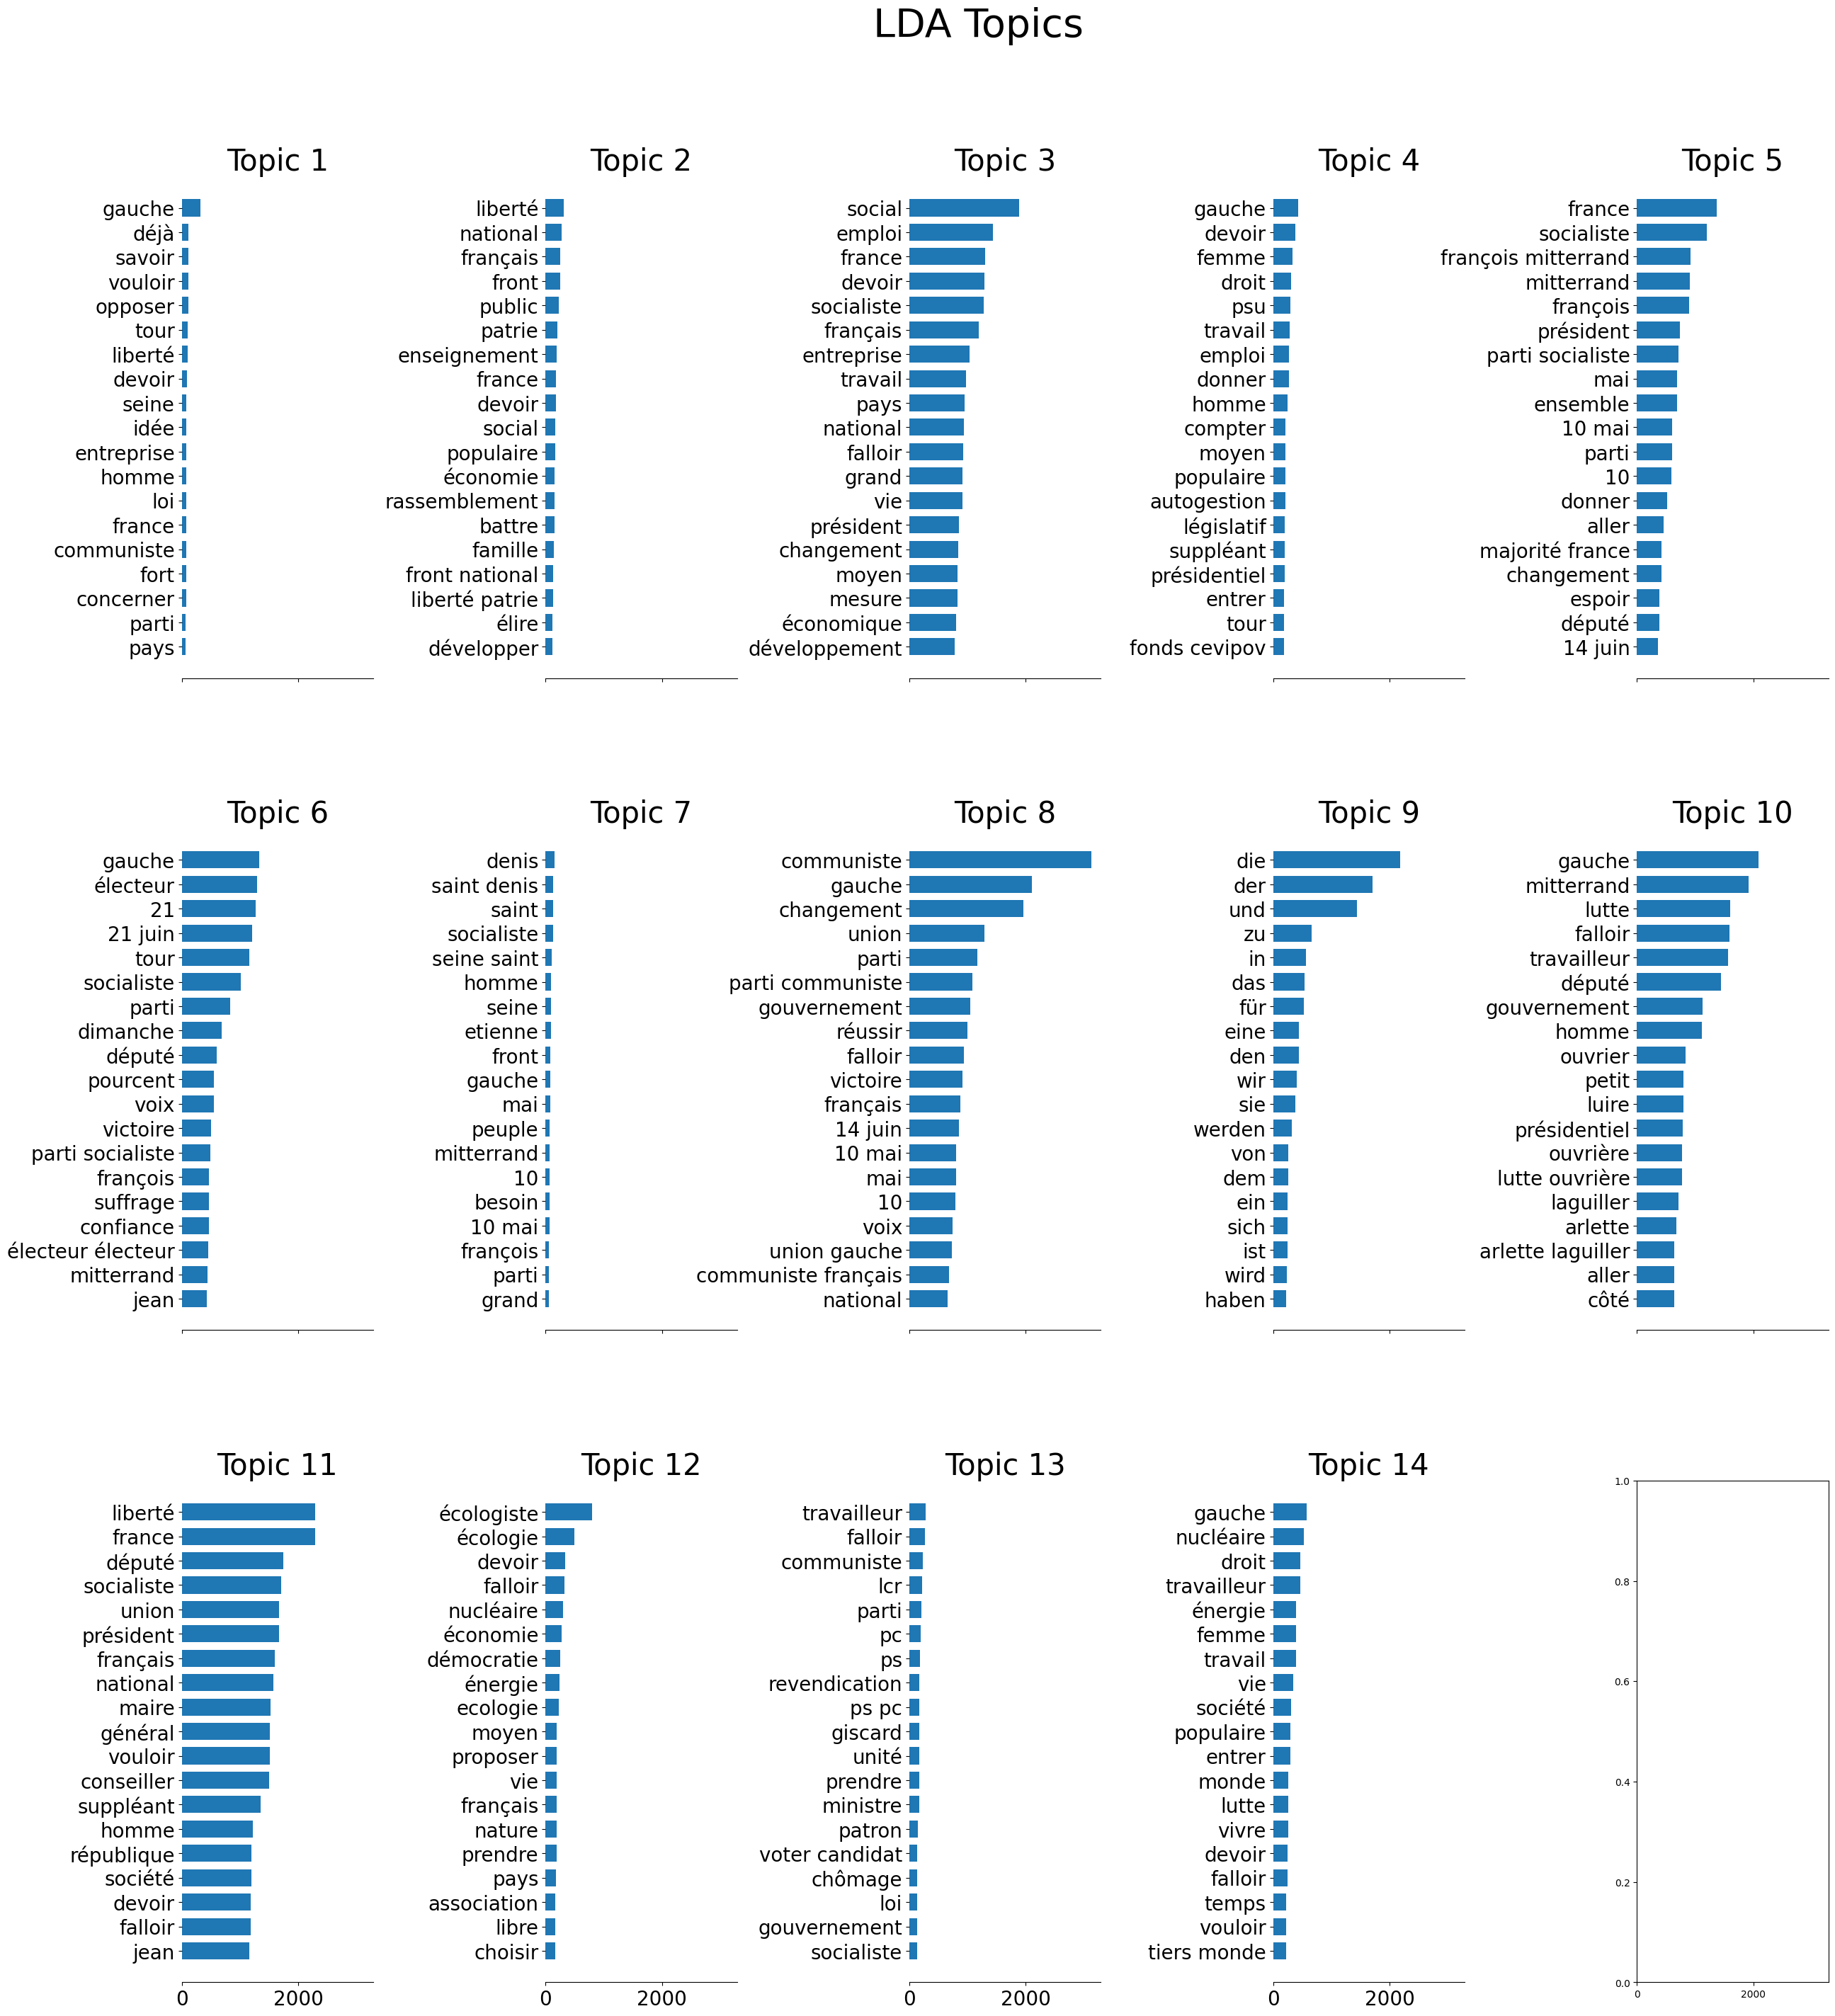

In [18]:
plot_top_words(lda, df_vectorizer, n_top_words=19, title="LDA Topics")